In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time
import numpy as np
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=32, shuffle=False, num_workers=2)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:02<00:00, 78.1MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [2]:
class VGG(nn.Module):
    def __init__(self):
        super(VGG, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.Dropout(0.25),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),

            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.Dropout(0.25),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.Dropout(0.25),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
            nn.Dropout(0.25),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.Dropout(0.25),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.Dropout(0.25),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [3]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

In [4]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert (
                self.head_dim * num_heads == embed_dim
        ), "Embedding dimension needs to be divisible by number of heads"

        self.qkv_proj = nn.Linear(embed_dim, 3 * embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        batch_size, seq_length, embed_dim = x.size()
        qkv = self.qkv_proj(x)
        qkv = qkv.reshape(batch_size, seq_length, self.num_heads, 3 * self.head_dim).permute(0, 2, 1, 3)
        q, k, v = qkv.chunk(3, dim=-1)
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        values = torch.matmul(attn_probs, v)
        values = values.permute(0, 2, 1, 3).reshape(batch_size, seq_length, embed_dim)
        out = self.out_proj(values)
        return out


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, in_channels=3, num_classes=10,
                 embed_dim=192, num_heads=3, num_layers=12, mlp_dim=768, dropout=0.1):
        super(ViT, self).__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.num_patches, embed_dim))
        self.dropout = nn.Dropout(dropout)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)
        for block in self.transformer_blocks:
            x = block(x)
        x = self.norm(x)
        cls_token_output = x[:, 0]
        out = self.head(cls_token_output)
        return out

In [5]:
import time
import copy

def train_model(model, model_name, trainloader, valloader, testloader, criterion, optimizer, epochs=5, patience=5):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)
    start_time = time.time()
    best_accuracy = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    no_improvement_count = 0
    train_losses = []
    train_accuracies = []
    val_accuracies = []
    epoch_times = []
    
    for epoch in range(epochs):
        epoch_start_time = time.time()
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(trainloader)
        train_accuracy = 100 * train_correct / train_total
        val_accuracy = evaluate_model(model, valloader)[0]
        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)
        
        print(f'Epoch {epoch + 1}/{epochs}, '
              f'Train Loss: {train_loss:.4f}, '
              f'Train Acc: {train_accuracy:.2f}%, '
              f'Val Acc: {val_accuracy:.2f}%, '
              f'Time: {epoch_time:.2f}s')
        
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, f'{model_name}_best_model.pth')
            no_improvement_count = 0
        else:
            no_improvement_count += 1
        
        if no_improvement_count >= patience:
            print(f'Early stopping at epoch {epoch + 1} due to no improvement in val accuracy.')
            break
    
    total_time = time.time() - start_time
    model.load_state_dict(best_model_wts)
    test_accuracy, inference_time = evaluate_model(model, testloader)
    print(f'\nTraining completed. Best val accuracy: {best_accuracy:.2f}%, '
          f'Test accuracy: {test_accuracy:.2f}%, '
          f'Total training time: {total_time:.2f}s')
    return {
        'model': model,
        'training_time': total_time,
        'best_accuracy': best_accuracy,
        'test_accuracy': test_accuracy,
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'epoch_times': epoch_times
    }

def evaluate_model(model, dataloader):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    start_time = time.time()
    
    with torch.no_grad():
        for data in dataloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    inference_time = time.time() - start_time
    accuracy = 100 * correct / total
    return accuracy, inference_time

In [6]:
def evaluate_model_final(model, dataloader, num_classes=10):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    class_correct = [0] * num_classes
    class_total = [0] * num_classes
    start_time = time.time()
    with torch.no_grad():
        for data in dataloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += (predicted[i] == label).item()
                class_total[label] += 1
    
    inference_time = time.time() - start_time
    overall_accuracy = 100 * correct / total
    class_accuracies = {}
    for i in range(num_classes):
        if class_total[i] > 0:
            class_accuracies[i] = 100 * class_correct[i] / class_total[i]
        else:
            class_accuracies[i] = 0.0
    
    return {
        'overall_accuracy': overall_accuracy,
        'inference_time': inference_time,
        'class_accuracies': class_accuracies,
        'class_correct': class_correct,
        'class_total': class_total
    }

In [7]:
total_times = {}
train_losses = {}
train_accuracies = {}
test_accuracies = {}
val_accuracies = {}
results = {}

Training VGG...
Epoch 1/10, Train Loss: 1.9251, Train Acc: 29.28%, Val Acc: 36.47%, Time: 36.83s
Epoch 2/10, Train Loss: 1.5250, Train Acc: 44.87%, Val Acc: 46.02%, Time: 35.37s
Epoch 3/10, Train Loss: 1.2914, Train Acc: 55.09%, Val Acc: 56.96%, Time: 35.71s
Epoch 4/10, Train Loss: 1.1171, Train Acc: 62.34%, Val Acc: 59.16%, Time: 36.67s
Epoch 5/10, Train Loss: 0.9891, Train Acc: 66.99%, Val Acc: 69.05%, Time: 36.70s
Epoch 6/10, Train Loss: 0.8772, Train Acc: 70.61%, Val Acc: 66.80%, Time: 36.74s
Epoch 7/10, Train Loss: 0.8118, Train Acc: 73.31%, Val Acc: 66.99%, Time: 36.97s
Epoch 8/10, Train Loss: 0.7633, Train Acc: 75.05%, Val Acc: 69.95%, Time: 37.23s
Epoch 9/10, Train Loss: 0.6983, Train Acc: 76.94%, Val Acc: 69.19%, Time: 37.26s
Epoch 10/10, Train Loss: 0.6506, Train Acc: 78.73%, Val Acc: 70.30%, Time: 37.27s

Training completed. Best val accuracy: 70.30%, Test accuracy: 70.45%, Total training time: 369.14s

Per-class Accuracy:
plane: 59.50% (595/1000)
car: 89.00% (890/1000)
bird

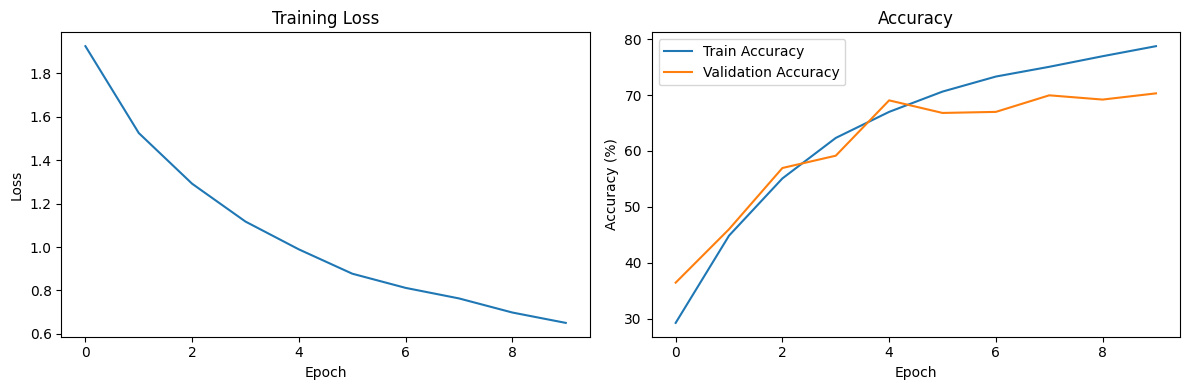

In [8]:
model_name = "VGG"
model = VGG() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
#optimizer = optim.Adam(model.parameters(), lr=0.01)  # 默认参数
training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training VGG...
Epoch 1/10, Train Loss: 1.7602, Train Acc: 33.99%, Val Acc: 37.62%, Time: 37.48s
Epoch 2/10, Train Loss: 1.3379, Train Acc: 51.45%, Val Acc: 52.71%, Time: 37.74s
Epoch 3/10, Train Loss: 1.1228, Train Acc: 59.80%, Val Acc: 55.55%, Time: 37.79s
Epoch 4/10, Train Loss: 0.9829, Train Acc: 65.50%, Val Acc: 64.20%, Time: 37.73s
Epoch 5/10, Train Loss: 0.8729, Train Acc: 69.73%, Val Acc: 67.20%, Time: 37.86s
Epoch 6/10, Train Loss: 0.7871, Train Acc: 73.07%, Val Acc: 72.48%, Time: 37.91s
Epoch 7/10, Train Loss: 0.7214, Train Acc: 75.31%, Val Acc: 69.94%, Time: 37.60s
Epoch 8/10, Train Loss: 0.6628, Train Acc: 77.19%, Val Acc: 71.93%, Time: 37.64s
Epoch 9/10, Train Loss: 0.6233, Train Acc: 78.70%, Val Acc: 77.21%, Time: 37.67s
Epoch 10/10, Train Loss: 0.5826, Train Acc: 80.12%, Val Acc: 77.46%, Time: 37.82s

Training completed. Best val accuracy: 77.46%, Test accuracy: 77.15%, Total training time: 380.00s

Per-class Accuracy:
plane: 68.60% (686/1000)
car: 85.40% (854/1000)
bird

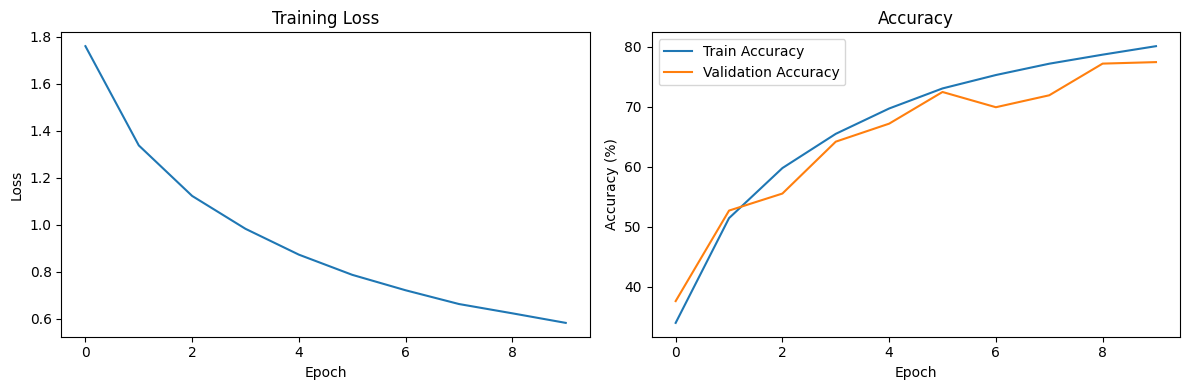

In [9]:
model_name = "VGG"
model = VGG() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
#optimizer = optim.Adam(model.parameters(), lr=0.01)  # 默认参数
training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training VGG...
Epoch 1/10, Train Loss: 2.9638, Train Acc: 10.21%, Val Acc: 9.81%, Time: 44.16s
Epoch 2/10, Train Loss: 2.3079, Train Acc: 10.12%, Val Acc: 9.87%, Time: 43.74s
Epoch 3/10, Train Loss: 2.3044, Train Acc: 9.86%, Val Acc: 10.20%, Time: 43.84s
Epoch 4/10, Train Loss: 2.5313, Train Acc: 10.11%, Val Acc: 10.10%, Time: 43.83s
Epoch 5/10, Train Loss: 2.3041, Train Acc: 9.94%, Val Acc: 9.87%, Time: 43.73s
Epoch 6/10, Train Loss: 2.3038, Train Acc: 10.05%, Val Acc: 9.74%, Time: 43.84s
Epoch 7/10, Train Loss: 2.3042, Train Acc: 10.09%, Val Acc: 9.87%, Time: 43.84s
Epoch 8/10, Train Loss: 2.3041, Train Acc: 9.89%, Val Acc: 9.69%, Time: 43.93s
Epoch 9/10, Train Loss: 2.3041, Train Acc: 9.87%, Val Acc: 9.81%, Time: 43.73s
Epoch 10/10, Train Loss: 2.3039, Train Acc: 9.89%, Val Acc: 10.10%, Time: 43.88s

Training completed. Best val accuracy: 10.20%, Test accuracy: 10.00%, Total training time: 439.58s

Per-class Accuracy:
plane: 0.00% (0/1000)
car: 0.00% (0/1000)
bird: 0.00% (0/1000)
c

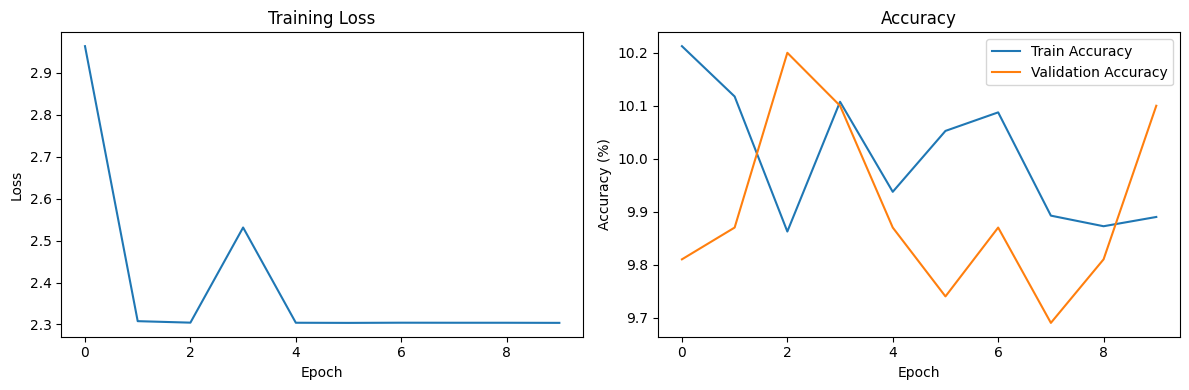

In [10]:
model_name = "VGG"
model = VGG() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
#optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
optimizer = optim.Adam(model.parameters(), lr=0.01)  # 默认参数
training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training VGG...
Epoch 1/10, Train Loss: 2.0056, Train Acc: 23.73%, Val Acc: 29.85%, Time: 44.82s
Epoch 2/10, Train Loss: 1.7264, Train Acc: 35.40%, Val Acc: 38.08%, Time: 45.10s
Epoch 3/10, Train Loss: 1.5420, Train Acc: 42.78%, Val Acc: 40.83%, Time: 44.83s
Epoch 4/10, Train Loss: 1.5016, Train Acc: 45.65%, Val Acc: 48.09%, Time: 44.61s
Epoch 5/10, Train Loss: 1.3008, Train Acc: 52.86%, Val Acc: 56.44%, Time: 44.63s
Epoch 6/10, Train Loss: 1.2451, Train Acc: 55.98%, Val Acc: 59.57%, Time: 44.66s
Epoch 7/10, Train Loss: 1.2325, Train Acc: 57.45%, Val Acc: 56.79%, Time: 44.63s
Epoch 8/10, Train Loss: 1.1250, Train Acc: 61.50%, Val Acc: 64.34%, Time: 44.59s
Epoch 9/10, Train Loss: 1.0872, Train Acc: 63.08%, Val Acc: 60.96%, Time: 44.95s
Epoch 10/10, Train Loss: 1.2180, Train Acc: 58.43%, Val Acc: 56.47%, Time: 44.80s

Training completed. Best val accuracy: 64.34%, Test accuracy: 63.47%, Total training time: 450.06s

Per-class Accuracy:
plane: 70.30% (703/1000)
car: 65.10% (651/1000)
bird

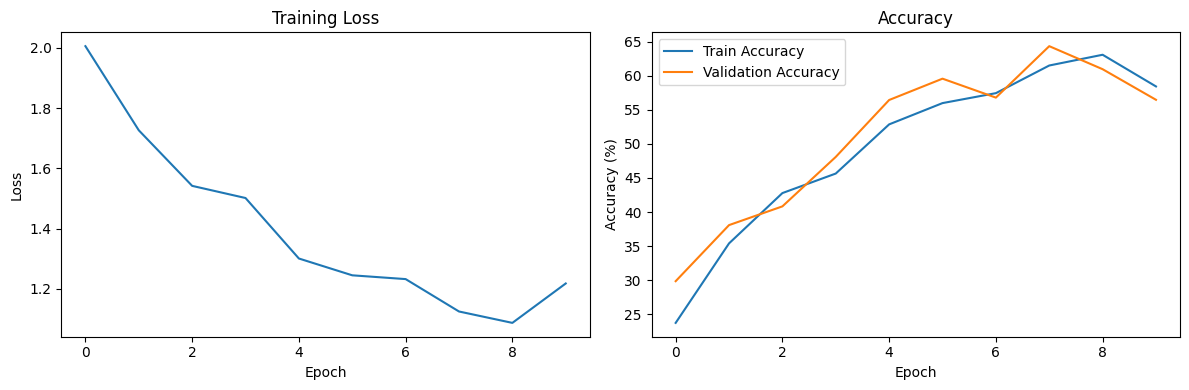

In [11]:
model_name = "VGG"
model = VGG() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
#optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 默认参数
training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training ResNet...
Epoch 1/10, Train Loss: 1.6165, Train Acc: 40.55%, Val Acc: 54.65%, Time: 46.23s
Epoch 2/10, Train Loss: 1.0973, Train Acc: 61.03%, Val Acc: 69.47%, Time: 45.76s
Epoch 3/10, Train Loss: 0.8429, Train Acc: 70.36%, Val Acc: 69.60%, Time: 45.71s
Epoch 4/10, Train Loss: 0.7074, Train Acc: 75.22%, Val Acc: 74.31%, Time: 45.83s
Epoch 5/10, Train Loss: 0.6117, Train Acc: 78.67%, Val Acc: 79.20%, Time: 45.93s
Epoch 6/10, Train Loss: 0.5467, Train Acc: 80.81%, Val Acc: 80.53%, Time: 45.82s
Epoch 7/10, Train Loss: 0.4883, Train Acc: 83.02%, Val Acc: 82.27%, Time: 45.87s
Epoch 8/10, Train Loss: 0.4495, Train Acc: 84.41%, Val Acc: 83.29%, Time: 46.43s
Epoch 9/10, Train Loss: 0.4142, Train Acc: 85.59%, Val Acc: 84.02%, Time: 46.14s
Epoch 10/10, Train Loss: 0.3814, Train Acc: 86.98%, Val Acc: 84.77%, Time: 46.28s

Training completed. Best val accuracy: 84.77%, Test accuracy: 85.24%, Total training time: 461.11s

Per-class Accuracy:
plane: 89.30% (893/1000)
car: 89.80% (898/1000)
b

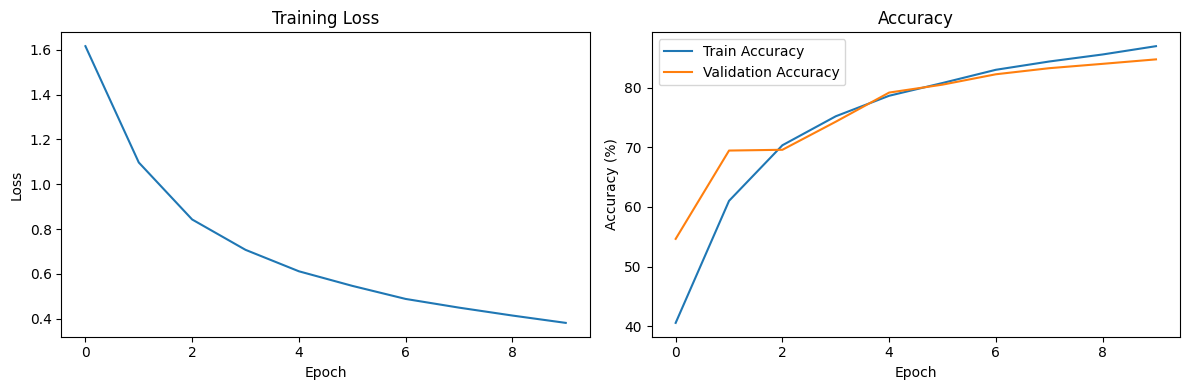

In [12]:
model_name = "ResNet"
model = ResNet18() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
#optimizer = optim.Adam(model.parameters(), lr=0.001)  # 默认参数
training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training ResNet...
Epoch 1/10, Train Loss: 1.4888, Train Acc: 45.38%, Val Acc: 52.29%, Time: 45.78s
Epoch 2/10, Train Loss: 1.0400, Train Acc: 62.99%, Val Acc: 66.88%, Time: 45.83s
Epoch 3/10, Train Loss: 0.8305, Train Acc: 70.87%, Val Acc: 73.01%, Time: 45.89s
Epoch 4/10, Train Loss: 0.7055, Train Acc: 75.22%, Val Acc: 76.23%, Time: 45.74s
Epoch 5/10, Train Loss: 0.6202, Train Acc: 78.52%, Val Acc: 76.70%, Time: 45.87s
Epoch 6/10, Train Loss: 0.5586, Train Acc: 80.56%, Val Acc: 78.54%, Time: 45.81s
Epoch 7/10, Train Loss: 0.5071, Train Acc: 82.29%, Val Acc: 82.29%, Time: 46.10s
Epoch 8/10, Train Loss: 0.4693, Train Acc: 83.73%, Val Acc: 82.88%, Time: 45.94s
Epoch 9/10, Train Loss: 0.4334, Train Acc: 84.93%, Val Acc: 81.82%, Time: 45.81s
Epoch 10/10, Train Loss: 0.4052, Train Acc: 85.88%, Val Acc: 84.51%, Time: 45.88s

Training completed. Best val accuracy: 84.51%, Test accuracy: 84.26%, Total training time: 459.64s

Per-class Accuracy:
plane: 83.30% (833/1000)
car: 94.10% (941/1000)
b

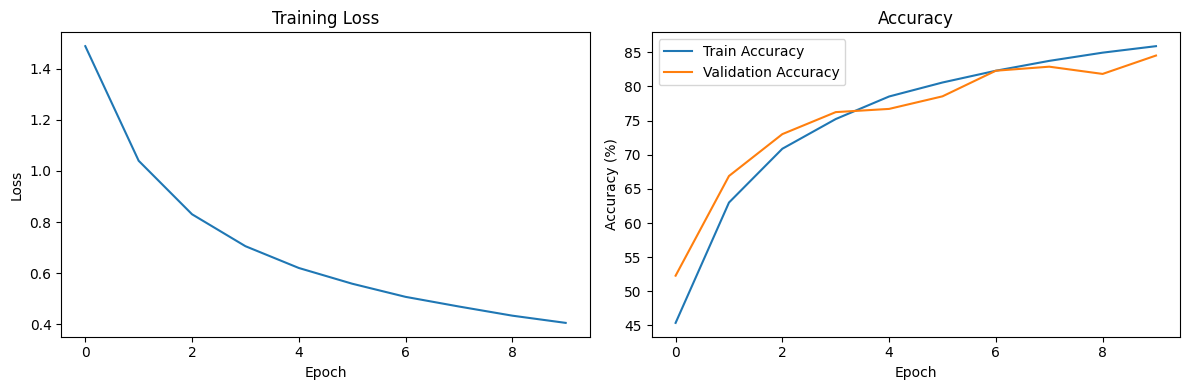

In [13]:
model_name = "ResNet"
model = ResNet18() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
#optimizer = optim.Adam(model.parameters(), lr=0.001)  # 默认参数
training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training ResNet...
Epoch 1/10, Train Loss: 1.8350, Train Acc: 31.56%, Val Acc: 41.46%, Time: 48.06s
Epoch 2/10, Train Loss: 1.3829, Train Acc: 49.44%, Val Acc: 53.55%, Time: 47.89s
Epoch 3/10, Train Loss: 1.0722, Train Acc: 61.80%, Val Acc: 65.95%, Time: 48.07s
Epoch 4/10, Train Loss: 0.8974, Train Acc: 68.33%, Val Acc: 70.48%, Time: 48.06s
Epoch 5/10, Train Loss: 0.7562, Train Acc: 73.52%, Val Acc: 75.42%, Time: 47.91s
Epoch 6/10, Train Loss: 0.6488, Train Acc: 77.46%, Val Acc: 78.07%, Time: 47.76s
Epoch 7/10, Train Loss: 0.5829, Train Acc: 79.97%, Val Acc: 79.61%, Time: 47.72s
Epoch 8/10, Train Loss: 0.5297, Train Acc: 81.56%, Val Acc: 81.96%, Time: 47.76s
Epoch 9/10, Train Loss: 0.4871, Train Acc: 82.97%, Val Acc: 82.97%, Time: 47.72s
Epoch 10/10, Train Loss: 0.4567, Train Acc: 84.17%, Val Acc: 82.75%, Time: 47.58s

Training completed. Best val accuracy: 82.97%, Test accuracy: 82.26%, Total training time: 479.53s

Per-class Accuracy:
plane: 78.90% (789/1000)
car: 94.20% (942/1000)
b

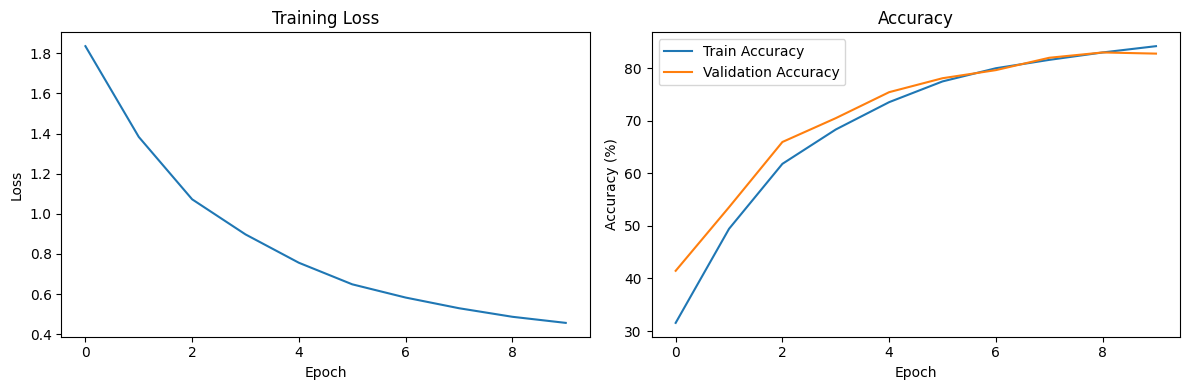

In [14]:
model_name = "ResNet"
model = ResNet18() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
#optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
optimizer = optim.Adam(model.parameters(), lr=0.01)  # 默认参数
training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training ResNet...
Epoch 1/10, Train Loss: 1.4967, Train Acc: 45.17%, Val Acc: 58.25%, Time: 48.11s
Epoch 2/10, Train Loss: 1.0525, Train Acc: 62.37%, Val Acc: 68.70%, Time: 48.22s
Epoch 3/10, Train Loss: 0.8354, Train Acc: 70.55%, Val Acc: 71.47%, Time: 48.20s
Epoch 4/10, Train Loss: 0.6921, Train Acc: 76.03%, Val Acc: 76.20%, Time: 48.17s
Epoch 5/10, Train Loss: 0.6005, Train Acc: 79.09%, Val Acc: 79.02%, Time: 48.17s
Epoch 6/10, Train Loss: 0.5388, Train Acc: 81.34%, Val Acc: 80.96%, Time: 48.11s
Epoch 7/10, Train Loss: 0.4767, Train Acc: 83.61%, Val Acc: 83.03%, Time: 48.09s
Epoch 8/10, Train Loss: 0.4310, Train Acc: 85.12%, Val Acc: 84.55%, Time: 48.15s
Epoch 9/10, Train Loss: 0.3933, Train Acc: 86.31%, Val Acc: 84.79%, Time: 48.14s
Epoch 10/10, Train Loss: 0.3630, Train Acc: 87.37%, Val Acc: 86.04%, Time: 48.30s

Training completed. Best val accuracy: 86.04%, Test accuracy: 85.95%, Total training time: 482.79s

Per-class Accuracy:
plane: 83.00% (830/1000)
car: 94.60% (946/1000)
b

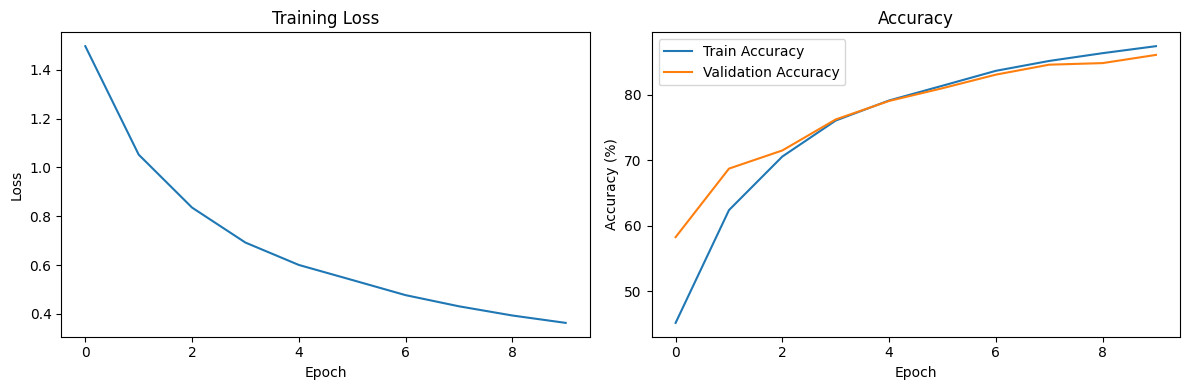

In [15]:
model_name = "ResNet"
model = ResNet18() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
#optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 默认参数
training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training ViT...
Epoch 1/10, Train Loss: 1.9261, Train Acc: 28.11%, Val Acc: 35.84%, Time: 53.12s
Epoch 2/10, Train Loss: 1.6804, Train Acc: 37.48%, Val Acc: 41.30%, Time: 52.68s
Epoch 3/10, Train Loss: 1.5707, Train Acc: 41.88%, Val Acc: 45.04%, Time: 52.68s
Epoch 4/10, Train Loss: 1.4918, Train Acc: 45.05%, Val Acc: 47.52%, Time: 52.54s
Epoch 5/10, Train Loss: 1.4275, Train Acc: 47.81%, Val Acc: 49.68%, Time: 52.81s
Epoch 6/10, Train Loss: 1.3872, Train Acc: 49.53%, Val Acc: 49.54%, Time: 52.79s
Epoch 7/10, Train Loss: 1.3463, Train Acc: 50.97%, Val Acc: 50.19%, Time: 52.73s
Epoch 8/10, Train Loss: 1.3099, Train Acc: 52.55%, Val Acc: 52.96%, Time: 52.66s
Epoch 9/10, Train Loss: 1.2816, Train Acc: 53.39%, Val Acc: 53.53%, Time: 52.24s
Epoch 10/10, Train Loss: 1.2489, Train Acc: 54.71%, Val Acc: 54.66%, Time: 52.45s

Training completed. Best val accuracy: 54.66%, Test accuracy: 54.85%, Total training time: 527.34s

Per-class Accuracy:
plane: 66.10% (661/1000)
car: 66.00% (660/1000)
bird

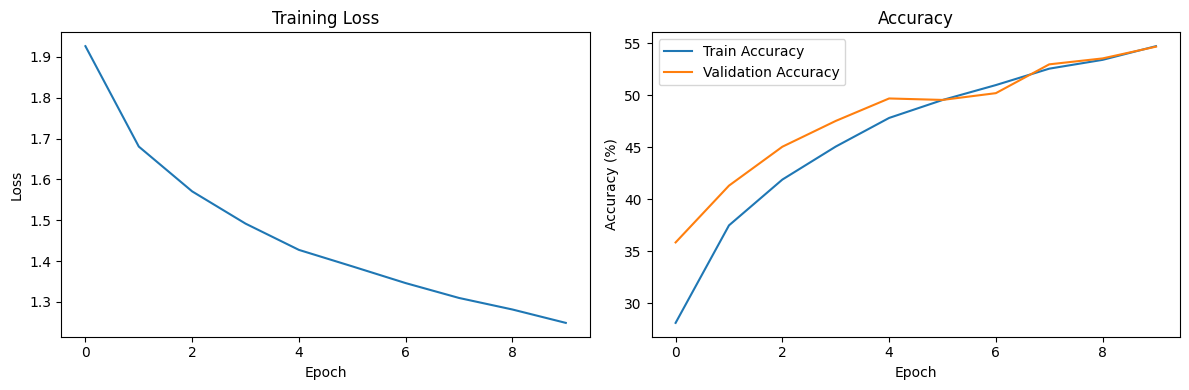

In [16]:
model_name = "ViT"
model = ViT() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training ViT...
Epoch 1/10, Train Loss: 1.8766, Train Acc: 29.64%, Val Acc: 33.50%, Time: 52.63s
Epoch 2/10, Train Loss: 1.7202, Train Acc: 35.67%, Val Acc: 39.41%, Time: 52.88s
Epoch 3/10, Train Loss: 1.6012, Train Acc: 41.00%, Val Acc: 42.79%, Time: 52.65s
Epoch 4/10, Train Loss: 1.5191, Train Acc: 44.26%, Val Acc: 44.90%, Time: 52.75s
Epoch 5/10, Train Loss: 1.4608, Train Acc: 46.77%, Val Acc: 47.56%, Time: 52.49s
Epoch 6/10, Train Loss: 1.4191, Train Acc: 48.37%, Val Acc: 49.12%, Time: 52.65s
Epoch 7/10, Train Loss: 1.3768, Train Acc: 49.79%, Val Acc: 51.13%, Time: 52.89s
Epoch 8/10, Train Loss: 1.3510, Train Acc: 50.84%, Val Acc: 52.66%, Time: 52.52s
Epoch 9/10, Train Loss: 1.3180, Train Acc: 52.18%, Val Acc: 51.46%, Time: 52.47s
Epoch 10/10, Train Loss: 1.2919, Train Acc: 52.82%, Val Acc: 54.21%, Time: 52.80s

Training completed. Best val accuracy: 54.21%, Test accuracy: 54.20%, Total training time: 527.35s

Per-class Accuracy:
plane: 52.40% (524/1000)
car: 59.20% (592/1000)
bird

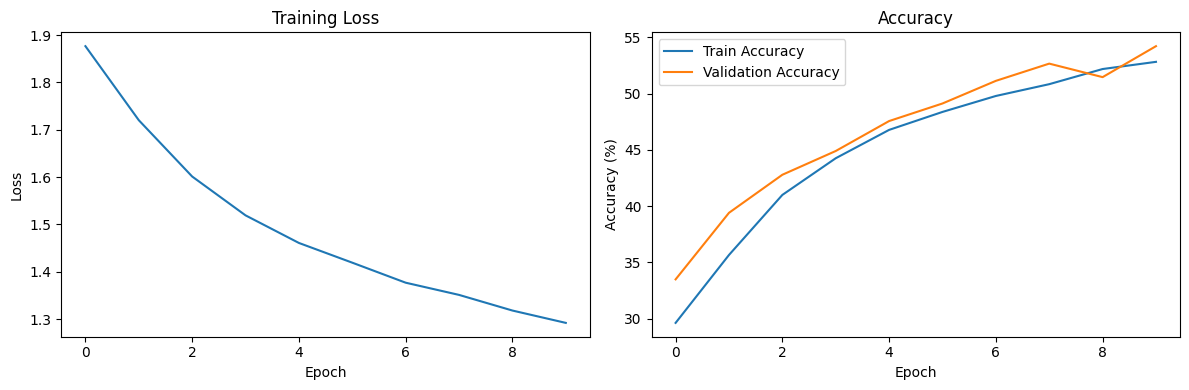

In [17]:
model_name = "ViT"
model = ViT() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training ViT...
Epoch 1/10, Train Loss: 2.1861, Train Acc: 17.12%, Val Acc: 11.34%, Time: 53.54s
Epoch 2/10, Train Loss: 2.2078, Train Acc: 15.76%, Val Acc: 17.28%, Time: 52.75s
Epoch 3/10, Train Loss: 2.1800, Train Acc: 16.55%, Val Acc: 16.40%, Time: 51.52s
Epoch 4/10, Train Loss: 2.1460, Train Acc: 17.91%, Val Acc: 15.02%, Time: 51.09s
Epoch 5/10, Train Loss: 2.1421, Train Acc: 18.17%, Val Acc: 16.80%, Time: 51.27s
Epoch 6/10, Train Loss: 2.1069, Train Acc: 19.39%, Val Acc: 20.34%, Time: 51.39s
Epoch 7/10, Train Loss: 2.1036, Train Acc: 19.50%, Val Acc: 19.07%, Time: 50.96s
Epoch 8/10, Train Loss: 2.1037, Train Acc: 19.71%, Val Acc: 17.85%, Time: 51.26s
Epoch 9/10, Train Loss: 2.1112, Train Acc: 19.39%, Val Acc: 20.13%, Time: 50.96s
Epoch 10/10, Train Loss: 2.0996, Train Acc: 19.69%, Val Acc: 20.52%, Time: 50.77s

Training completed. Best val accuracy: 20.52%, Test accuracy: 20.48%, Total training time: 515.81s

Per-class Accuracy:
plane: 24.40% (244/1000)
car: 10.80% (108/1000)
bird

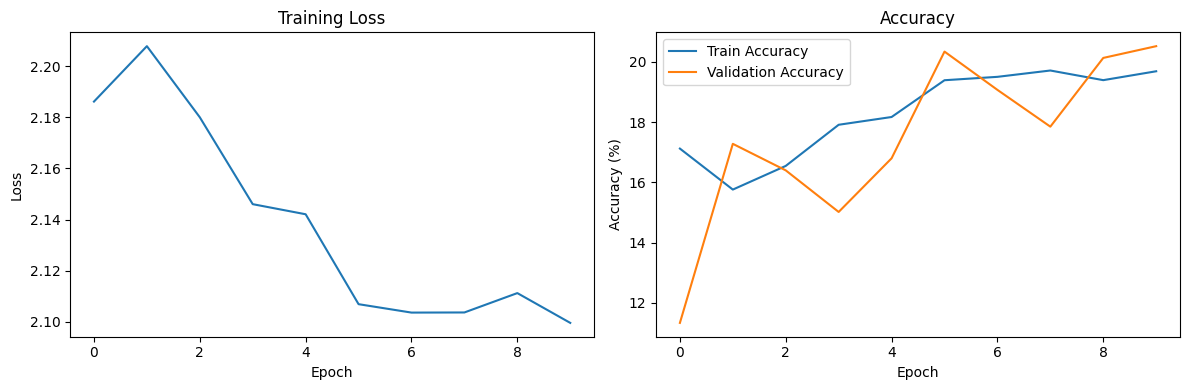

In [18]:
model_name = "ViT"
model = ViT() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)  # 默认参数

training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training ViT...
Epoch 1/10, Train Loss: 1.9601, Train Acc: 25.35%, Val Acc: 28.06%, Time: 53.83s
Epoch 2/10, Train Loss: 1.7963, Train Acc: 31.48%, Val Acc: 33.90%, Time: 54.20s
Epoch 3/10, Train Loss: 1.7859, Train Acc: 32.76%, Val Acc: 29.69%, Time: 54.11s
Epoch 4/10, Train Loss: 1.7799, Train Acc: 33.23%, Val Acc: 32.62%, Time: 54.07s
Epoch 5/10, Train Loss: 1.7828, Train Acc: 33.19%, Val Acc: 34.15%, Time: 54.09s
Epoch 6/10, Train Loss: 1.7662, Train Acc: 33.87%, Val Acc: 34.57%, Time: 54.08s
Epoch 7/10, Train Loss: 1.7896, Train Acc: 33.21%, Val Acc: 34.03%, Time: 53.99s
Epoch 8/10, Train Loss: 1.7543, Train Acc: 34.85%, Val Acc: 36.06%, Time: 53.98s
Epoch 9/10, Train Loss: 1.7778, Train Acc: 33.60%, Val Acc: 34.70%, Time: 53.99s
Epoch 10/10, Train Loss: 1.7958, Train Acc: 33.30%, Val Acc: 34.08%, Time: 54.05s

Training completed. Best val accuracy: 36.06%, Test accuracy: 36.77%, Total training time: 540.74s

Per-class Accuracy:
plane: 47.50% (475/1000)
car: 41.80% (418/1000)
bird

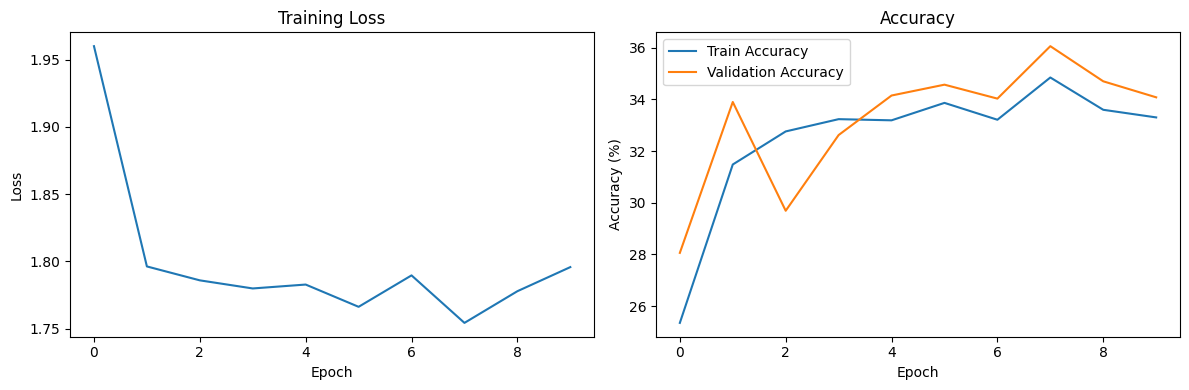

In [19]:
model_name = "ViT"
model = ViT() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 默认参数

training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=10, patience=10
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()